# 项目：英国电商公司销售数据进行评估、清洗、保存、可视化

## 分析目标

此数据分析的目的是，根据市场销售数据，挖掘畅销产品，以便制定更有效的市场策略来提升营收。

本实战项目的目的在于练习评估数据干净和整洁度，并且基于评估结果，对数据进行清洗，从而得到可供下一步分析的数据。

## 简介

原始数据集记录了一家英国在线零售公司在2010年12月1日至2011年12月9日期间的所有交易情况，涵盖了该公司在全球不同国家和地区的业务数据。该公司主要销售覆盖各个场景的礼品，包括但不限于生日礼品、结婚纪念品、圣诞礼品等等。该公司的客户群体主要包括批发商和个人消费者，其中批发商占据了相当大的比例。

数据每列的含义如下：
- `InvoiceNo`: 发票号码。6位数，作为交易的唯一标识符。如果这个代码以字母“c”开头，表示这笔交易被取消。
- `StockCode`: 产品代码。5位数，作为产品的唯一标识符。
- `Description`: 产品名称。
- `Quantity`: 产品在交易中的数量。
- `InvoiceDate`: 发票日期和时间。交易发生的日期和时间。
- `UnitPrice`: 单价。价格单位为英镑（£）。
- `CustomerID`: 客户编号。5位数，作为客户的唯一标识符。
- `Country`: 国家名称。客户所居住的国家的名称。

## 一、读取数据

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("e_commerce.csv")

In [3]:
original_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 二、评估数据

### （一）评估整齐度

##### 每列是一个变量/字段，每行是一个观察值的完整数据，每个单元格是一个值

In [4]:
original_data.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
438855,574336,22941,CHRISTMAS LIGHTS 10 REINDEER,6,11/4/2011 9:52,8.50,12397.0,Belgium
375977,569491,23503,PLAYING CARDS KEEP CALM & CARRY ON,2,10/4/2011 13:25,1.25,14056.0,United Kingdom
295306,562780,23344,JUMBO BAG 50'S CHRISTMAS,6,8/9/2011 13:03,2.08,14901.0,United Kingdom
447145,574950,21669,BLUE STRIPE CERAMIC DRAWER KNOB,2,11/8/2011 9:29,3.29,NaN,United Kingdom
519298,580140,23111,PARISIENNE SEWING BOX,2,12/2/2011 9:19,12.50,14895.0,United Kingdom
327561,565677,23445,ICE CREAM BUBBLES,20,9/6/2011 10:04,0.83,15521.0,United Kingdom
381058,569846,22623,BOX OF VINTAGE JIGSAW BLOCKS,3,10/6/2011 13:42,5.95,13422.0,United Kingdom
302926,563482,84997D,CHILDRENS CUTLERY POLKADOT PINK,1,8/16/2011 15:54,4.15,17097.0,Spain
501922,578833,22457,NATURAL SLATE HEART CHALKBOARD,2,11/25/2011 15:23,5.79,NaN,United Kingdom
429516,573564,22668,PINK BABY BUNTING,5,10/31/2011 13:58,2.95,16127.0,United Kingdom


### （二）评估干净度

##### 干净度说明：1. 查看行列数量、字段类型、缺失值（核心！）
##### 2. 统计每一列缺失数据总量
##### 3. 统计重复行数
##### 4. 数字字段统计，快速筛查异常值（负数、极值）
##### 5. 抽样查看原始内容，观察文本脏数据

In [5]:
original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


##### 1、评估缺失数据，观察info方法的结果：
##### 1.1 总共8个字段、541,909行，其中Description（产品名称）\CustomerID（客户ID）有缺失值，接下来要根据条件提取缺失观察值
##### 1.1.1 Description缺失说明：从打印结果看，产品名称缺失的交易数据没有产品单价，因此无效，选择删除该部分数据
##### 1.1.2 CustomerID缺失说明：从打印结果看，客户ID缺失的交易数据同样有效并且可用于数据分析，因此保留
##### 1.2 从数据类型来看，InvoiceDate的数据类型改为日期，CustomerID的数据类型改为字符串
##### 2、评估重复数据：该数据表的字段可以存在重复，因此无需评估重复
##### 3、评估不一致数据：Country可能存在不一致，即不同值指代同一个国家。从排查结果来看，英国、美国的数据不一致，在【清洗】步骤进行统一
##### 4、评估无效/错误数据：使用DataFrame的describe方法
##### 4.1 Quantity为负数时，表示退货、订单取消、单价为0元，为无效数据，后续应删除
##### 4.2 UnitPrice为负数时，表示坏账调账，为无效数据，后续应删除

In [6]:
original_data[original_data["Description"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [7]:
original_data[(original_data["Description"].isnull()) & (original_data["UnitPrice"] != 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [8]:
original_data[original_data["CustomerID"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [9]:
original_data["Country"].value_counts().sort_index()

Country
Australia                 1259
Austria                    401
Bahrain                     19
Belgium                   2069
Brazil                      32
Canada                     151
Channel Islands            758
China                      288
Cyprus                     622
Czech Republic              30
Denmark                    389
EIRE                      8196
European Community          61
Finland                    695
France                    8557
Germany                   9495
Greece                     146
Iceland                    182
Israel                     297
Italy                      803
Japan                      358
Lebanon                     45
Lithuania                   35
Malta                      127
Netherlands               2371
Norway                    1086
Poland                     341
Portugal                  1519
RSA                         58
Saudi Arabia                10
Singapore                  229
Spain                     2533


In [10]:
original_data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
original_data[original_data["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [12]:
original_data[(original_data["Quantity"] < 0)&(original_data["InvoiceNo"].str[0] != "C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/2011 18:36,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom


In [13]:
original_data[(original_data["Quantity"] < 0)&(original_data["InvoiceNo"].str[0] != "C")&(original_data["UnitPrice"] != 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [14]:
original_data[original_data["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


## 三、清理数据

根据上一步评估结果，需要进行清理的数据如下：
- Description缺失值删除
- InvoiceDate数据类型改为日期时间
- CustomerID数据类型改为字符串
- Country中的USA改为United States
- Country中的UK、U.K.改为United Kingdom
- Quantity负数值删除
- UnitPrice负数值删除

In [15]:
cleaned_data = original_data.copy()
cleaned_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
cleaned_data = cleaned_data.dropna(subset = ["Description"])
cleaned_data["Description"].isnull().sum()

np.int64(0)

In [17]:
cleaned_data["InvoiceDate"] = pd.to_datetime(cleaned_data["InvoiceDate"])
cleaned_data["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 540455, dtype: datetime64[us]

In [18]:
cleaned_data["CustomerID"] = cleaned_data["CustomerID"].astype(str)
cleaned_data["CustomerID"] = cleaned_data["CustomerID"].str.slice(0,-2)
cleaned_data["CustomerID"]

0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
541904    12680
541905    12680
541906    12680
541907    12680
541908    12680
Name: CustomerID, Length: 540455, dtype: str

In [19]:
country_replace = {
    "USA":"United State",
    "UK":"United Kingdom",
    "U.K.":"United Kingdom"
}
cleaned_data["Country"] = cleaned_data["Country"].replace(country_replace)

In [20]:
cleaned_data = cleaned_data[cleaned_data["Quantity"] >= 0]

In [21]:
cleaned_data = cleaned_data[cleaned_data["UnitPrice"] >= 0]

In [22]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice
count,530691.000000,530691,530691.000000
mean,10.605855,2011-07-04 19:01:11.249597,3.903303
min,1.000000,2010-12-01 08:26:00,0.000000
25%,1.000000,2011-03-28 11:59:00,1.250000
50%,3.000000,2011-07-20 12:14:00,2.080000
75%,10.000000,2011-10-19 12:35:00,4.130000
max,80995.000000,2011-12-09 12:50:00,13541.330000
std,156.638147,NaN,35.896047


## 四、保存清理后的数据

把干净整齐的数据保存到e_commerce_cleaned.csv

In [23]:
cleaned_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [24]:
cleaned_data.to_csv("e_commerce_cleaned.csv", index = False, encoding = "utf-8-sig")

In [25]:
pd.read_csv("e_commerce_cleaned.csv").head()

C:\Users\sandy\AppData\Local\Temp\ipykernel_16508\2686214642.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("e_commerce_cleaned.csv").head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [26]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 530691 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530691 non-null  str           
 1   StockCode    530691 non-null  str           
 2   Description  530691 non-null  str           
 3   Quantity     530691 non-null  int64         
 4   InvoiceDate  530691 non-null  datetime64[us]
 5   UnitPrice    530691 non-null  float64       
 6   CustomerID   397924 non-null  str           
 7   Country      530691 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 36.4 MB


## 五、数据可视化

### （一）rcParams全局设置，新增SalesAmount衍生字段

In [32]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

cleaned_data["SalesAmount"] = cleaned_data["Quantity"] * cleaned_data["UnitPrice"]

cleaned_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### （二）图表1：月度销售额折线图
目的：分析全年销售淡旺季

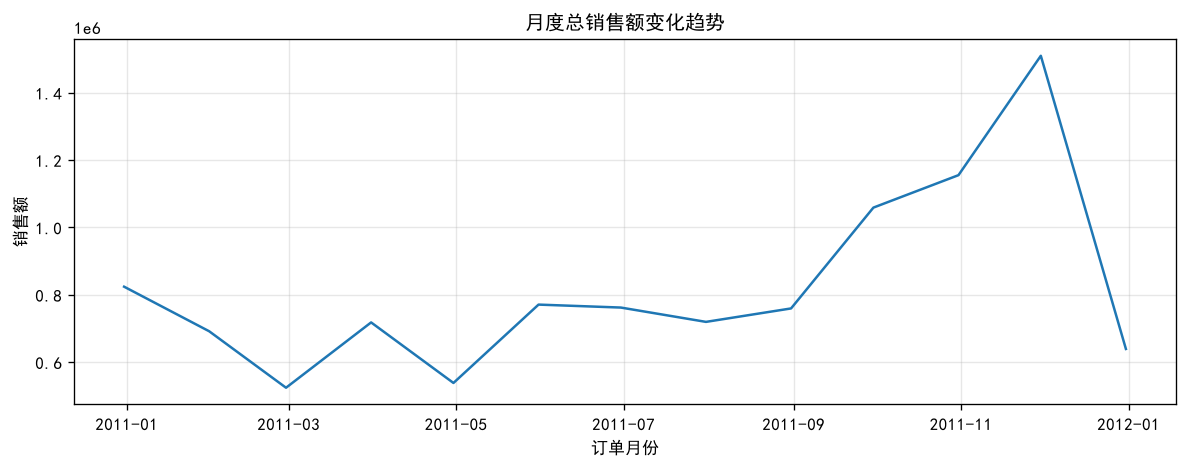

In [41]:
monthly_sales = cleaned_data.resample('ME', on = 'InvoiceDate')["SalesAmount"].sum()

plt.figure(figsize = (10,4))
sns.lineplot(data = monthly_sales)

plt.title("月度总销售额变化趋势")
plt.xlabel("订单月份")
plt.ylabel("销售额")
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.savefig("month_sales_trend.png")
plt.show()

### （三）图表2：各国销售额柱状图
目的：分析各国销售量

<function matplotlib.pyplot.show(close=None, block=None)>

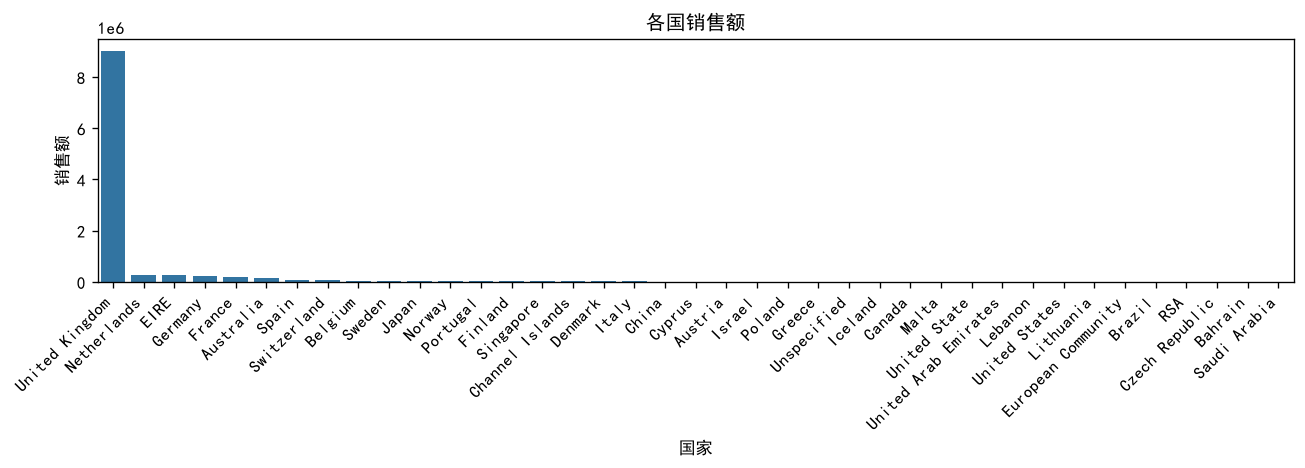

In [42]:
country_sales = cleaned_data.groupby("Country")["SalesAmount"].sum().sort_values(ascending = False)

plt.figure(figsize = (11,4))
sns.barplot(x = country_sales.index, y = country_sales.values)

plt.title("各国销售额")
plt.xlabel("国家")
plt.ylabel("销售额")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()

plt.savefig("country_sales.png")
plt.show

### （四）图表3：Quantity直方图

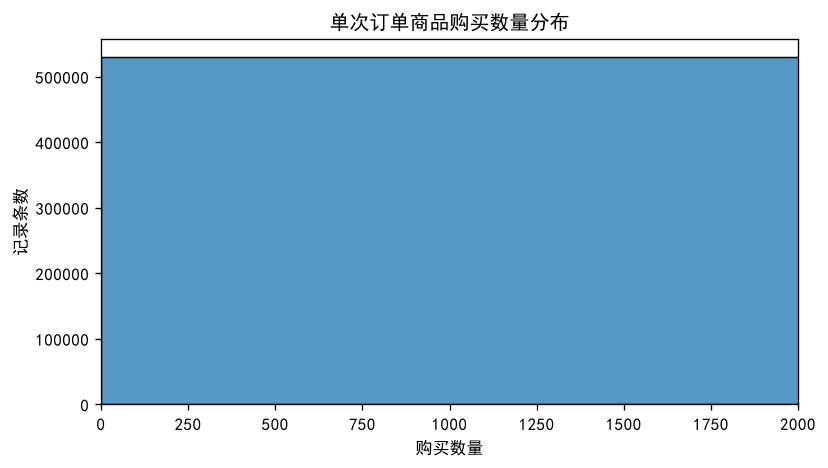

In [49]:
plt.figure(figsize = (7,4))
sns.histplot(data = cleaned_data, x = "Quantity", bins = 40)

plt.xlim(0,2000)

plt.title("单次订单商品购买数量分布")
plt.xlabel("购买数量")
plt.ylabel("记录条数")
plt.tight_layout()

plt.savefig("quantity_hist.png")
plt.show()

### （五）图表4：Quantity箱线图（清洗校验）

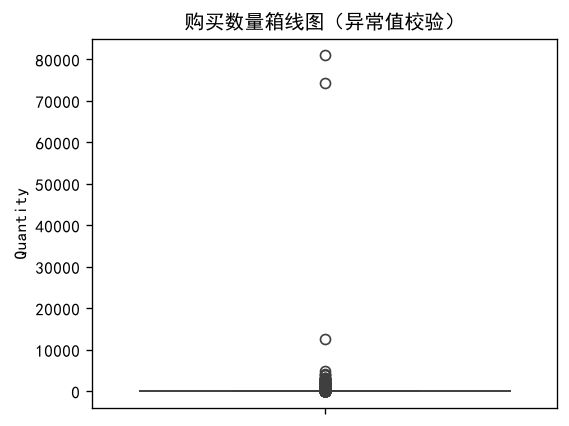

In [52]:
plt.figure(figsize = (5,4))
sns.boxplot(data = cleaned_data, y = "Quantity")

plt.title("购买数量箱线图（异常值校验）")
plt.tight_layout
plt.show()

### （六）图表5：客户下单频次分布

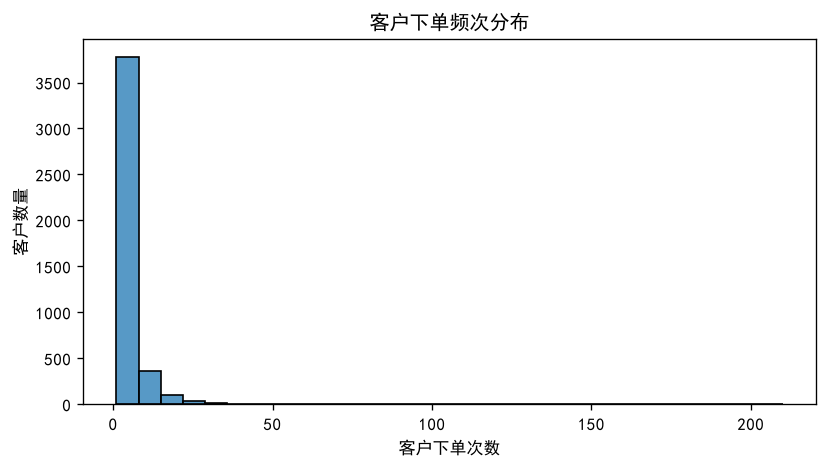

In [55]:
cust_order_count = cleaned_data.dropna(subset = ["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure(figsize = (7,4))
sns.histplot(cust_order_count, bins = 30)

plt.title("客户下单频次分布")
plt.xlabel("客户下单次数")
plt.ylabel("客户数量")
plt.tight_layout()

plt.savefig("customer_order_count.png")
plt.show()